In [9]:
import torch
torch_version = torch.__version__.split('+')[0]
scatter_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
sparse_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
!pip install torch-scatter -f $scatter_src
!pip install torch-sparse -f $sparse_src
!pip install torch-geometric
!pip install pyg-lib
!pip install scikit-learn
!pip install -q git+https://github.com/snap-stanford/deepsnap.git

Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2.html


ERROR: Could not find a version that satisfies the requirement pyg-lib (from versions: none)
ERROR: No matching distribution found for pyg-lib


  ERROR: Error [WinError 2] The system cannot find the file specified while executing command git clone -q https://github.com/snap-stanford/deepsnap.git 'C:\Users\SRMAPCSELAB2022-346\AppData\Local\Temp\pip-req-build-ooqxt5_0'
ERROR: Cannot find command 'git' - do you have 'git' installed and in your PATH?


In [10]:
import torch
print(torch.__version__)

2.2.2+cpu


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
from sklearn.model_selection import train_test_split
from torch_geometric.data import HeteroData
from torch_geometric.utils import dropout_edge, negative_sampling
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import trange
import time
import matplotlib.pyplot as plt
import requests
import zipfile
import io
import os
import pandas as pd
from collections import defaultdict

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_scatter import scatter_add
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {seed}")

class SGL(nn.Module):

    def __init__(
            self,
            num_users,
            num_items,
            hidden_size=256,
            num_layers=3,
            edge_dropout=0.1,
            temperature=0.2,
            ssl_weight=0.1,
            reg_weight=1e-3):

        super().__init__()

        self.num_users = num_users
        self.num_items = num_items

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.temperature = temperature
        self.ssl_weight = ssl_weight
        self.reg_weight = reg_weight

        self.edge_dropout_prob = edge_dropout

        ####################################################
        # Embeddings
        ####################################################

        self.user_embeddings = nn.Embedding(
            num_users,
            hidden_size
        )

        self.item_embeddings = nn.Embedding(
            num_items,
            hidden_size
        )

        nn.init.xavier_uniform_(
            self.user_embeddings.weight
        )

        nn.init.xavier_uniform_(
            self.item_embeddings.weight
        )

    ########################################################
    # Standard Edge Dropout
    ########################################################

    def edge_dropout(
            self,
            edge_index,
            p=None):

        if p is None:
            p = self.edge_dropout_prob

        if (not self.training) or p == 0:
            return edge_index

        mask = (
            torch.rand(
                edge_index.size(1),
                device=edge_index.device
            ) > p
        )

        return edge_index[:, mask]

    ########################################################
    # Generate Two Views
    ########################################################

    def generate_views(
            self,
            edge_index):

        view1 = self.edge_dropout(
            edge_index
        )

        view2 = self.edge_dropout(
            edge_index
        )

        return view1, view2

    ########################################################
    # LightGCN Propagation
    ########################################################

    def propagate(
            self,
            user_emb,
            item_emb,
            edge_index):

        x = torch.cat(
            [user_emb, item_emb],
            dim=0
        )

        embeddings = [x]

        src = edge_index[0]
        dst = edge_index[1] + self.num_users
        
        edge_index = torch.cat([
            torch.stack([src, dst], dim=0),
            torch.stack([dst, src], dim=0)
        ], dim=1)

        src = edge_index[0]
        dst = edge_index[1]
        
        num_nodes = x.size(0)
        
        edge_weight = torch.ones(
            edge_index.size(1),
            device=edge_index.device
        )

           
        deg = scatter_add(
             edge_weight,
             src,
             dim=0,
             dim_size=num_nodes
        )

        deg = deg.clamp(min=1)

        for _ in range(self.num_layers):

            norm = (
                deg[src].pow(-0.5)
                *
                deg[dst].pow(-0.5)
            )

            x = scatter_add(
                x[src] * norm.unsqueeze(-1),
                dst,
                dim=0,
                dim_size=num_nodes
            )

            embeddings.append(x)

        final_embedding = (
            torch.stack(
                embeddings,
                dim=0
            ).mean(dim=0)
        )

        user_embedding = (
            final_embedding[
                :self.num_users
            ]
        )

        item_embedding = (
            final_embedding[
                self.num_users:
            ]
        )

        return (
            user_embedding,
            item_embedding
        )

    ########################################################
    # Forward
    ########################################################

    def forward(
            self,
            edge_index,
            return_views=False):

        user_emb = (
            self.user_embeddings.weight
        )

        item_emb = (
            self.item_embeddings.weight
        )

        if self.training and return_views:

            view1, view2 = (
                self.generate_views(
                    edge_index
                )
            )

            emb1 = self.propagate(
                user_emb,
                item_emb,
                view1
            )

            emb2 = self.propagate(
                user_emb,
                item_emb,
                view2
            )

            return emb1, emb2

        return self.propagate(
            user_emb,
            item_emb,
            edge_index
        )

    ########################################################
    # Prediction
    ########################################################

    def predict(
            self,
            user_emb,
            item_emb,
            user_ids,
            item_ids):

        u = user_emb[user_ids]

        i = item_emb[item_ids]

        return torch.sum(
            u * i,
            dim=-1
        )

    ########################################################
    # InfoNCE Loss
    ########################################################

    def contrastive_loss(
        self,
        emb1,
        emb2,
        max_samples=2048):

        if emb1.size(0) > max_samples:

            idx = torch.randperm(
                emb1.size(0),
                device=emb1.device
            )[:max_samples]

            emb1 = emb1[idx]
            emb2 = emb2[idx]

        z1 = F.normalize(
            emb1,
            dim=1
        )

        z2 = F.normalize(
            emb2,
            dim=1
        )

        logits = (
            torch.mm(
                z1,
                z2.t()
            ) / self.temperature
        )

        labels = torch.arange(
            z1.size(0),
            device=z1.device
        )

        loss1 = F.cross_entropy(
            logits,
            labels
        )

        loss2 = F.cross_entropy(
            logits.t(),
            labels
        )

        return (loss1 + loss2) / 2
        
       

    ########################################################
    # BPR Loss
    ########################################################

    def bpr_loss(
            self,
            user_emb,
            item_emb,
            pos_edge_index,
            neg_edge_index):

        pos_scores = self.predict(
            user_emb,
            item_emb,
            pos_edge_index[0],
            pos_edge_index[1]
        )

        neg_scores = self.predict(
            user_emb,
            item_emb,
            neg_edge_index[0],
            neg_edge_index[1]
        )

        bpr = -torch.log(
            torch.sigmoid(
                pos_scores -
                neg_scores
            ) + 1e-12
        ).mean()

        reg_loss = (
            self.user_embeddings.weight
            .norm(2).pow(2)
            +
            self.item_embeddings.weight
            .norm(2).pow(2)
        )

        reg_loss = (
            self.reg_weight *
            reg_loss
        )

        return bpr + reg_loss

    ########################################################
    # Total Loss
    ########################################################

    def total_loss(
        self,
        pos_edge_index,
        neg_edge_index,
        edge_index):

        

        main_user_emb, main_item_emb = self.forward(
            edge_index,
            return_views=False
        )

        

        (
            (user_emb1, item_emb1),
            (user_emb2, item_emb2)
        ) = self.forward(
            edge_index,
            return_views=True
        )

        
        bpr = self.bpr_loss(
            main_user_emb,
            main_item_emb,
            pos_edge_index,
            neg_edge_index
        )

        

        user_ssl = self.contrastive_loss(
            user_emb1,
            user_emb2
        )

        

        item_ssl = self.contrastive_loss(
            item_emb1,
            item_emb2
        )

        

        ssl = (user_ssl + item_ssl) / 2

        total = (
            bpr +
            self.ssl_weight * ssl
        )

        

        return total, bpr, ssl

Random seed set to 42


In [13]:
from torch_geometric.utils import negative_sampling

def prepare_sgl_data(data, val_ratio=0.1, test_ratio=0.1):
    """Prepare data for  training on Gowalla"""

    # Gowalla graph
    edge_index = data.edge_index

    num_edges = edge_index.size(1)
    perm = torch.randperm(num_edges)

    num_val = int(num_edges * val_ratio)
    num_test = int(num_edges * test_ratio)
    num_train = num_edges - num_val - num_test

    train_idx = perm[:num_train]
    val_idx = perm[num_train:num_train + num_val]
    test_idx = perm[num_train + num_val:]

    train_pos_edge_index = edge_index[:, train_idx]
    val_pos_edge_index = edge_index[:, val_idx[:10000]]
    test_pos_edge_index = edge_index[:, test_idx[:10000]]

   
    
    num_users = data.num_users
    num_items = data.num_items

    
        
    #max_train_edges = min(train_pos_edge_index.size(1), 1000000)
    max_train_edges = min(train_pos_edge_index.size(1), 200000) 

    train_pos_edge_index = (
        train_pos_edge_index[:, :max_train_edges]
    )

    # Generate exactly one negative sample for each positive edge
    train_neg = negative_sampling(
        edge_index=train_pos_edge_index,
        num_nodes=(num_users, num_items),
        num_neg_samples=train_pos_edge_index.size(1)
    )
    
 
    val_neg = negative_sampling(
        edge_index=train_pos_edge_index,
        num_nodes=(num_users, num_items),
        num_neg_samples=val_pos_edge_index.size(1)
    )
    
    

       
    test_neg = negative_sampling(
        edge_index=train_pos_edge_index,
        num_nodes=(num_users, num_items),
        num_neg_samples=test_pos_edge_index.size(1)
    )
    
    
    
    data.train_pos_edge_index = train_pos_edge_index
    data.train_neg_edge_index = train_neg

    data.val_edge_index = torch.cat(
        [val_pos_edge_index, val_neg],
        dim=1
    )

    data.val_edge_label = torch.cat(
        [
            torch.ones(val_pos_edge_index.size(1)),
            torch.zeros(val_neg.size(1))
        ]
    )

    data.test_edge_index = torch.cat(
        [test_pos_edge_index, test_neg],
        dim=1
    )

    data.test_edge_label = torch.cat(
        [
            torch.ones(test_pos_edge_index.size(1)),
            torch.zeros(test_neg.size(1))
        ]
    )
    
    print("\nData Split Statistics")
    print("-" * 40)

    print(
        "Train Positives:",
        data.train_pos_edge_index.shape
    )

    print(
        "Train Negatives:",
        data.train_neg_edge_index.shape
    )

    print(
        "Validation edges:",
        data.val_edge_index.shape
    )

    print(
        "Validation labels:",
        data.val_edge_label.shape
    )

    print(
        "Test edges:",
        data.test_edge_index.shape
    )

    print(
        "Test labels:",
        data.test_edge_label.shape
    )

    return data



def train_sgl_with_data_sgl(data, config):
    """Train SGL model on Gowalla"""

    device = config.get(
        'device',
        torch.device(
            'cuda' if torch.cuda.is_available() else 'cpu'
        )
    )
    
    print("Starting prepare_sgl_data")

    data = prepare_sgl_data(data)
    
    print("Finished prepare_sgl_data")
    
       
    graph_edge_index = data.train_pos_edge_index.to(device)

    
    print("Graph edges:", graph_edge_index.shape)
    print("Train positives:", data.train_pos_edge_index.shape)
    print("Train negatives:", data.train_neg_edge_index.shape)
    
    
    data.train_pos_edge_index = data.train_pos_edge_index.to(device)
    data.train_neg_edge_index = data.train_neg_edge_index.to(device)

    data.val_edge_index = data.val_edge_index.to(device)
    data.val_edge_label = data.val_edge_label.to(device)

    data.test_edge_index = data.test_edge_index.to(device)
    data.test_edge_label = data.test_edge_label.to(device)

       
        
    model = SGL(
    num_users=data.num_users,
    num_items=data.num_items,
    hidden_size=config.get('hidden_size', 32),
    num_layers=config.get('num_layers', 1),
    edge_dropout=config.get('edge_dropout', 0.1),
    temperature=config.get('temperature', 0.2),
    ssl_weight=config.get('ssl_weight', 0.05),
    reg_weight=config.get('reg_weight', 1e-3)
    ).to(device)

       
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config.get('learning_rate', 1e-3),
        weight_decay=config.get('weight_decay', 1e-6)
    )

    num_epochs = config.get('epochs', 1)

    losses = []
    val_aucs = []

    best_val_auc = 0.0
    best_model_state = None

    

    print("Training SGL Model...")

    for epoch in trange(
        num_epochs,
        desc="SGL Training"
    ):

        model.train()

        optimizer.zero_grad()

        total_loss, bpr_loss, ssl_loss = model.total_loss(
            data.train_pos_edge_index,
            data.train_neg_edge_index,
            graph_edge_index
        )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0
        )

        optimizer.step()
        
        
        losses.append({
            'total_loss': total_loss.item(),
            'bpr_loss': bpr_loss.item(),
            'ssl_loss': ssl_loss.item()
        })

        if epoch % 5 == 0:
            
            

            model.eval()

            with torch.no_grad():
                
                

                user_emb, item_emb = model(
                    graph_edge_index
                )

                val_scores = model.predict(
                    user_emb,
                    item_emb,
                    data.val_edge_index[0],
                    data.val_edge_index[1]
                )

                val_scores = torch.sigmoid(
                    val_scores
                )

                val_auc = roc_auc_score(
                    data.val_edge_label.cpu().numpy(),
                    val_scores.cpu().numpy()
                )

            val_aucs.append(val_auc)

            if val_auc > best_val_auc:

                best_val_auc = val_auc

                best_model_state = {
                    k: v.cpu().clone()
                    for k, v in model.state_dict().items()
                }

    if False and best_model_state is not None:

        model.load_state_dict(
            best_model_state
        )

    ####################################################
    # Test Evaluation
    ####################################################

    model.eval()

    with torch.no_grad():

        user_emb, item_emb = model(
            graph_edge_index
        )

        test_scores = model.predict(
            user_emb,
            item_emb,
            data.test_edge_index[0],
            data.test_edge_index[1]
        )

        test_scores = torch.sigmoid(
            test_scores
        )

        test_auc = roc_auc_score(
            data.test_edge_label.cpu().numpy(),
            test_scores.cpu().numpy()
        )

        test_ap = average_precision_score(
            data.test_edge_label.cpu().numpy(),
            test_scores.cpu().numpy()
        )

        test_metrics = {
            'AUC': test_auc,
            'AP': test_ap
        }
        
        print("Starting Recommendation Evaluation")

        ''' rec_metrics = {
            'HR@5': 0,
            'HR@10': 0,
            'HR@20': 0,
            'NDCG@5': 0,
            'NDCG@10': 0,
            'NDCG@20': 0,
            'MRR': 0
        } '''
        
        rec_metrics = evaluate_recommendation_clean(model, data, k_list=[5, 10, 20])
        
        print("Recommendation Evaluation Finished")
   
    return {
        'model': model,
        'losses': losses,
        'val_aucs': val_aucs,
        'test_metrics': test_metrics,
        'rec_metrics': rec_metrics,
        'best_val_auc': best_val_auc
    }
      

## Training and Testing

In [14]:
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
import numpy as np
from torch_geometric.data import HeteroData
import requests
import zipfile
import io
import copy
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import trange
import torch
import torch.nn.functional as F
from torch_geometric.utils import negative_sampling
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split
import numpy as np
import os
import torch
from torch_geometric.data import Data


def download_and_extract_gowalla():
    """
    Extract Gowalla dataset from uploaded ZIP file
    and return the actual dataset directory.
    """

    print("Extracting Gowalla dataset...")

    zip_file = "gowalla.zip"

    extract_path = "gowalla"

    # Create extraction directory
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)

    # Extract ZIP
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print("Dataset extracted successfully!")

    print(f"Files extracted to: {extract_path}")

    print("\nDirectory structure:")

    for root, dirs, files in os.walk(extract_path):

        level = root.replace(
            extract_path,
            ''
        ).count(os.sep)

        indent = ' ' * 2 * level

        print(
            f"{indent}"
            f"{os.path.basename(root)}/"
        )

        subindent = ' ' * 2 * (level + 1)

        for file in files[:10]:

            print(
                f"{subindent}"
                f"{file}"
            )

   

    dataset_folder = os.path.join(
        extract_path,
        "gowalla"
    )

    if os.path.exists(dataset_folder):

        print(
            "\nGowalla dataset folder found:"
        )

        print(dataset_folder)

        print("\nDataset files:")

        for file in os.listdir(dataset_folder):

            print(f"  - {file}")

        return dataset_folder

    # Fallback
    print(
        "\nWarning:"
        " Gowalla folder not found."
    )

    return extract_path

def encode_user_features(num_users):
    """
    Create user features for Gowalla.
    Gowalla has no user profile features.
    """

    user_features = torch.ones(
        (num_users, 1),
        dtype=torch.float32
    )

    print("Gowalla User Info:")
    print(f"  Number of users: {num_users}")
    print(f"  User feature dimension: {user_features.shape[1]}")

    return user_features

def encode_item_features(num_items):
    """
    Create default item features.

    The dataset does not provide explicit item feature vectors.
    SGL learns item embeddings directly, so a constant feature
    vector is used.
    """

    item_features = torch.ones(
        (num_items, 1),
        dtype=torch.float32
    )

    print("Gowalla Item Info:")
    print(f"  Number of items: {num_items}")
    print(f"  Item feature dimension: {item_features.shape[1]}")

    return item_features


def load_gowalla_dataset(
    data_path,
    use_features=True,
    use_temporal=False
):
    """
    Load Gowalla dataset
    """

    print(f"Loading Gowalla dataset from: {data_path}")

    train_file = os.path.join(
        data_path,
        "train.txt"
    )

    test_file = os.path.join(
        data_path,
        "test.txt"
    )

    if not os.path.exists(train_file):
        raise FileNotFoundError(train_file)

    if not os.path.exists(test_file):
        raise FileNotFoundError(test_file)

    user_nodes = []
    item_nodes = []

    max_user = 0
    max_item = 0

    print("Reading training interactions...")

    with open(train_file, "r") as f:

        for line in f:

            arr = line.strip().split()

            if len(arr) <= 1:
                continue

            user = int(arr[0])

            max_user = max(
                max_user,
                user
            )

            for item in arr[1:]:

                item = int(item)

                user_nodes.append(user)
                item_nodes.append(item)

                max_item = max(
                    max_item,
                    item
                )

    num_users = max_user + 1
    num_items = max_item + 1

    edge_index = torch.tensor(
        [
            user_nodes,
            item_nodes
        ],
        dtype=torch.long
    )

    data = Data()

    data.edge_index = edge_index

    data.num_users = num_users
    data.num_items = num_items
    data.num_nodes = num_users + num_items
    
    print(f"Num Users : {num_users}")
    print(f"Num Items : {num_items}")
    print(f"Num Nodes : {data.num_nodes}")
    print(f"Num Edges : {edge_index.size(1)}")

    if use_features:

        user_features = encode_user_features(
            num_users
        )

        item_features = encode_item_features(
            num_items
        )

        data.user_features = user_features
        data.item_features = item_features

        user_feat_dim = user_features.shape[1]
        item_feat_dim = item_features.shape[1]

    else:

        user_feat_dim = 0
        item_feat_dim = 0

    print("\nFINAL STATISTICS")
    print(f"Users: {num_users}")
    print(f"Items: {num_items}")
    print(f"Training Interactions: {edge_index.size(1)}")
    print(f"User Feature Dimension: {user_feat_dim}")
    print(f"Item Feature Dimension: {item_feat_dim}")

    return (
        data,
        user_feat_dim,
        item_feat_dim
    )

def train_link_prediction_model(data, model, configuration):
    """Train SGL model on Gowalla"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=configuration.learning_rate,
        weight_decay=configuration.weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=configuration.epochs, eta_min=1e-6
    )

    # Data movement to device
    train_pos_edge_index = data.train_pos_edge_index.to(device)
    train_neg_edge_index = data.train_neg_edge_index.to(device)

    edge_index = train_pos_edge_index
    
    
    val_edge_index = data.val_edge_index.to(device)
    val_edge_label = data.val_edge_label.to(device)
    test_edge_index = data.test_edge_index.to(device)
    test_edge_label = data.test_edge_label.to(device)

    losses = []
    val_aucs = []
    best_val_auc = 0.0
    best_model_state = None

    trainer = SGLTrainer(
        model, learning_rate=configuration.learning_rate, device=device
    )
    
    print("Starting Training...")
    print(f"Train edges: {train_pos_edge_index.size(1)}")
    print(f"Val edges: {val_edge_index.size(1)}")
    print(f"Test edges: {test_edge_index.size(1)}")

    for epoch in trange(configuration.epochs, desc="SGL Training"):
        print(f"\nEpoch {epoch} started")
        loss_dict = trainer.train_epoch(
        edge_index,
        train_pos_edge_index,
        train_neg_edge_index
        )
        
        scheduler.step()
        losses.append(loss_dict["total_loss"])

        if epoch % 5 == 0:
            val_metrics = trainer.evaluate_link_prediction(
                edge_index, val_edge_index, val_edge_label
            )
            val_auc = val_metrics["AUC"]
            val_aucs.append(val_auc)

            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_model_state = {
                    k: v.cpu().clone() for k, v in model.state_dict().items()
                }

    if False and best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        test_metrics = trainer.evaluate_link_prediction(
            edge_index, test_edge_index, test_edge_label
        )

    return val_aucs, losses, model, test_metrics


@torch.no_grad()
def evaluate_recommendation_clean(model, data, k_list=[5, 10, 20]):
    """
    Evaluate recommendation performance on test set.
    """
    model.eval()
    device = next(model.parameters()).device

    HR = {k: [] for k in k_list}
    NDCG = {k: [] for k in k_list}
    MRR = []

    # Get positive test edges (only the positive ones)
    test_edge_label = data.test_edge_label.cpu()
    test_edge_index = data.test_edge_index.cpu()
    
    # Filter to only positive edges (label=1)
    pos_mask = test_edge_label == 1
    pos_edges = test_edge_index[:, pos_mask]
    
    print("=" * 50)
    print("RECOMMENDATION EVALUATION")
    print("=" * 50)
    print(f"Positive test edges: {pos_edges.size(1)}")

    if pos_edges.size(1) == 0:
        print("ERROR: No positive test edges found!")
        results = {}
        for k in k_list:
            results[f"HR@{k}"] = 0.0
            results[f"NDCG@{k}"] = 0.0
        results["MRR"] = 0.0
        return results

    # For faster evaluation, sample a reasonable number of users
    max_eval_users = min(500, pos_edges.size(1))
    
    # Get unique users from positive test edges
    unique_users = torch.unique(pos_edges[0])
    if len(unique_users) > max_eval_users:
        idx = torch.randperm(len(unique_users))[:max_eval_users]
        test_users = unique_users[idx]
    else:
        test_users = unique_users

    # Get all items
    all_items = set(range(data.num_items))
    
    # Build training items per user (to exclude from recommendation)
    train_pos = data.train_pos_edge_index.cpu()
    user_train_items = {}
    for i in range(train_pos.size(1)):
        user = train_pos[0, i].item()
        item = train_pos[1, i].item()
        if user not in user_train_items:
            user_train_items[user] = set()
        user_train_items[user].add(item)
        
    # Build test positive items per user
    user_test_items = {}

    for i in range(pos_edges.size(1)):
        user = pos_edges[0, i].item()
        item = pos_edges[1, i].item()

        if user not in user_test_items:
            user_test_items[user] = set()

        user_test_items[user].add(item)    

    # Get embeddings once
    with torch.no_grad():
        user_emb, item_emb = model(data.train_pos_edge_index.to(device))

    # For each test user, evaluate recommendations
    for user in test_users:
        user = user.item()
        
        # Get the positive items for this user from test set
        user_pos_mask = pos_edges[0] == user
        user_pos_items = pos_edges[1, user_pos_mask].tolist()
        
        if not user_pos_items:
            continue
            
        # For each positive item, compute rank
        for pos_item in user_pos_items:
            # Get all known positive items for this user
            seen_items = user_train_items.get(user, set()).copy()

            # Exclude all positive test items for this user
            seen_items.update(user_test_items.get(user, set()))

            # Allow the current positive item to be evaluated
            seen_items.discard(pos_item)

            # Candidate items are all unseen items
            candidate_items = list(all_items - seen_items)
            
            if len(candidate_items) < 499:
                continue
                
            # Sample 499 negative items
            negative_items = np.random.choice(candidate_items, size=499, replace=False)
            candidates = list(negative_items) + [pos_item]
            
            # Get predictions for all candidates
            users_tensor = torch.full((len(candidates),), user, dtype=torch.long, device=device)
            items_tensor = torch.tensor(candidates, dtype=torch.long, device=device)
            
            scores = model.predict(user_emb, item_emb, users_tensor, items_tensor)
            scores = scores.cpu().numpy()
            
            # Rank items
            ranking = np.argsort(scores)[::-1]  # descending
            ranked_items = [candidates[i] for i in ranking]
            rank = ranked_items.index(pos_item) + 1
            
            # Store metrics
            MRR.append(1.0 / rank)
            
            for k in k_list:
                if rank <= k:
                    HR[k].append(1)
                    NDCG[k].append(1.0 / np.log2(rank + 1))
                else:
                    HR[k].append(0)
                    NDCG[k].append(0)

    # Compute final results
    results = {}
    for k in k_list:
        results[f"HR@{k}"] = np.mean(HR[k]) if len(HR[k]) > 0 else 0.0
        results[f"NDCG@{k}"] = np.mean(NDCG[k]) if len(NDCG[k]) > 0 else 0.0
    
    results["MRR"] = np.mean(MRR) if len(MRR) > 0 else 0.0
    
        
    return results

class Config:
    def __init__(self, parameters):
        self.__dict__.update(parameters)        

In [15]:
from torch_geometric.utils import negative_sampling

def prepare_link_prediction_data(
    data,
    val_ratio=0.05,
    test_ratio=0.05
):

    edge_index = data.edge_index

    num_edges = edge_index.size(1)

    perm = torch.randperm(num_edges)

    num_val = int(
        num_edges * val_ratio
    )

    num_test = int(
        num_edges * test_ratio
    )

    num_train = (
        num_edges
        - num_val
        - num_test
    )

    train_idx = perm[:num_train]

    val_idx = perm[
        num_train:
        num_train + num_val
    ]

    test_idx = perm[
        num_train + num_val:
    ]

    train_pos_edge_index = (
        edge_index[:, train_idx]
    )

    val_pos_edge_index = (
        edge_index[:, val_idx]
    )

    test_pos_edge_index = (
        edge_index[:, test_idx]
    )

    # ----------------------------------
    # Limit training size for Gowalla
    # ----------------------------------

    max_train_edges = min(
        train_pos_edge_index.size(1),
        1000000
    )

    train_pos_edge_index = (
        train_pos_edge_index[
            :,
            :max_train_edges
        ]
    )

    # ----------------------------------
    # Negative Sampling
    # ----------------------------------

    train_neg_edge_index = negative_sampling(
        edge_index=train_pos_edge_index,
        num_nodes=(
            data.num_users,
            data.num_items
        ),
        num_neg_samples=max_train_edges
    )

    val_neg_edge_index = negative_sampling(
        edge_index=train_pos_edge_index,
        num_nodes=(
            data.num_users,
            data.num_items
        ),
        num_neg_samples=
        val_pos_edge_index.size(1)
    )

    test_neg_edge_index = negative_sampling(
        edge_index=train_pos_edge_index,
        num_nodes=(
            data.num_users,
            data.num_items
        ),
        num_neg_samples=
        test_pos_edge_index.size(1)
    )

    # ----------------------------------
    # Train
    # ----------------------------------

    data.train_pos_edge_index = (
        train_pos_edge_index
    )

    data.train_neg_edge_index = (
        train_neg_edge_index
    )

    data.train_edge_index = torch.cat(
        [
            train_pos_edge_index,
            train_neg_edge_index
        ],
        dim=1
    )

    data.train_edge_label = torch.cat(
        [
            torch.ones(
                train_pos_edge_index.size(1)
            ),
            torch.zeros(
                train_neg_edge_index.size(1)
            )
        ]
    )

    # ----------------------------------
    # Validation
    # ----------------------------------

    data.val_edge_index = torch.cat(
        [
            val_pos_edge_index,
            val_neg_edge_index
        ],
        dim=1
    )

    data.val_edge_label = torch.cat(
        [
            torch.ones(
                val_pos_edge_index.size(1)
            ),
            torch.zeros(
                val_neg_edge_index.size(1)
            )
        ]
    )

    # ----------------------------------
    # Test
    # ----------------------------------

    data.test_edge_index = torch.cat(
        [
            test_pos_edge_index,
            test_neg_edge_index
        ],
        dim=1
    )

    data.test_edge_label = torch.cat(
        [
            torch.ones(
                test_pos_edge_index.size(1)
            ),
            torch.zeros(
                test_neg_edge_index.size(1)
            )
        ]
    )

    return data

Using device: cpu

STEP 1: Loading Gowalla Dataset
Loading Gowalla dataset from: ./gowalla/gowalla
Reading training interactions...
Num Users : 29858
Num Items : 40981
Num Nodes : 70839
Num Edges : 810128
Gowalla User Info:
  Number of users: 29858
  User feature dimension: 1
Gowalla Item Info:
  Number of items: 40981
  Item feature dimension: 1

FINAL STATISTICS
Users: 29858
Items: 40981
Training Interactions: 810128
User Feature Dimension: 1
Item Feature Dimension: 1

Dataset Statistics:
Users: 29858
Items: 40981
Interactions: 810128
User Feature Dim: 1
Item Feature Dim: 1

STEP 2: Training SGL Model
Starting prepare_sgl_data

Data Split Statistics
----------------------------------------
Train Positives: torch.Size([2, 200000])
Train Negatives: torch.Size([2, 200000])
Validation edges: torch.Size([2, 20000])
Validation labels: torch.Size([20000])
Test edges: torch.Size([2, 20000])
Test labels: torch.Size([20000])
Finished prepare_sgl_data
Graph edges: torch.Size([2, 200000])
Train 

SGL Training: 100%|██████████████████████████████████████████████████████████████████| 300/300 [02:30<00:00,  2.00it/s]


Starting Recommendation Evaluation
RECOMMENDATION EVALUATION
Positive test edges: 10000
Recommendation Evaluation Finished

FINAL RESULTS - SGL
Model: SGL
Dataset: Gowalla

--- LINK PREDICTION METRICS ---
AUC: 0.7537
AP: 0.7742

--- RECOMMENDATION METRICS ---
HR@5: 0.1471
HR@10: 0.2214
HR@20: 0.3061
NDCG@5: 0.1010
NDCG@10: 0.1248
NDCG@20: 0.1467
MRR: 0.1096
Time Taken: 156.69 seconds


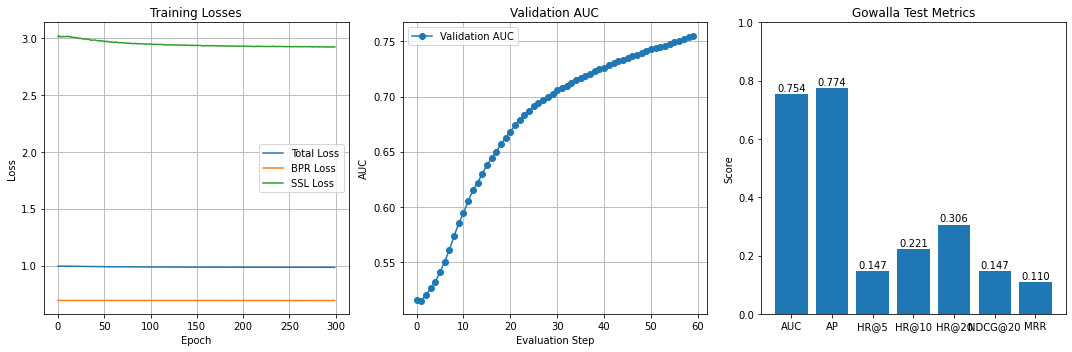

In [16]:
def main_gr_mc():
    """Main function to run SGL on Gowalla dataset"""

    config = {
        'model_type': 'SGL',
        'dataset': 'Gowalla',

        'device': torch.device(
            'cuda'
            if torch.cuda.is_available()
            else 'cpu'
        ),

        'hidden_size': 64,
        'num_layers': 2,

        'edge_dropout': 0.2,
        'temperature': 0.2,
        'ssl_weight': 0.1,
        'reg_weight': 1e-6,

        'learning_rate': 1e-3,
        'epochs': 300
        
    }

    print(
        f"Using device: {config['device']}"
    )

    print("\n" + "=" * 60)
    print("STEP 1: Loading Gowalla Dataset")
    print("=" * 60)

    gowalla_path = "./gowalla/gowalla"   # Change if needed

    data, user_feat_dim, item_feat_dim = (
        load_gowalla_dataset(
            gowalla_path,
            use_features=True
        )
    )

    print("\nDataset Statistics:")
    print(f"Users: {data.num_users}")
    print(f"Items: {data.num_items}")
    print(f"Interactions: {data.edge_index.size(1)}")
    print(f"User Feature Dim: {user_feat_dim}")
    print(f"Item Feature Dim: {item_feat_dim}")

    data = data.to(
        config['device']
    )

    print("\n" + "=" * 60)
    print("STEP 2: Training SGL Model")
    print("=" * 60)

    start_time = time.time()

    results = train_sgl_with_data_sgl(
        data,
        config
    )

    end_time = time.time()

    print("\n" + "=" * 60)
    print("FINAL RESULTS - SGL")
    print("=" * 60)

    print(
        f"Model: {config['model_type']}"
    )

    print(
        f"Dataset: {config['dataset']}"
    )

    print("\n--- LINK PREDICTION METRICS ---")

    print(
        f"AUC: {results['test_metrics']['AUC']:.4f}"
    )

    print(
        f"AP: {results['test_metrics']['AP']:.4f}"
    )

    print("\n--- RECOMMENDATION METRICS ---")

    print(f"HR@5: {results['rec_metrics']['HR@5']:.4f}")
    print(f"HR@10: {results['rec_metrics']['HR@10']:.4f}")
    print(f"HR@20: {results['rec_metrics']['HR@20']:.4f}")

    print(f"NDCG@5: {results['rec_metrics']['NDCG@5']:.4f}")

    print(
        f"NDCG@10: {results['rec_metrics']['NDCG@10']:.4f}"
    )

    print(
        f"NDCG@20: {results['rec_metrics']['NDCG@20']:.4f}"
    )

    print(
        f"MRR: {results['rec_metrics']['MRR']:.4f}"
    )

    print(
        f"Time Taken: {end_time - start_time:.2f} seconds"
    )

    plt.figure(figsize=(15, 5))

    # Training Loss
    plt.subplot(1, 3, 1)

    losses_array = [
        l['total_loss']
        for l in results['losses']
    ]

    plt.plot(
        losses_array,
        label='Total Loss'
    )

    plt.plot(
        [
            l['bpr_loss']
            for l in results['losses']
        ],
        label='BPR Loss'
    )

    plt.plot(
        [
            l['ssl_loss']
            for l in results['losses']
        ],
        label='SSL Loss'
    )

    plt.title('Training Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Validation AUC
    plt.subplot(1, 3, 2)

    plt.plot(
        results['val_aucs'],
        marker='o',
        label='Validation AUC'
    )

    plt.title('Validation AUC')
    plt.xlabel('Evaluation Step')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(True)

    # Final Metrics
    plt.subplot(1, 3, 3)

    metrics = [
        'AUC',
        'AP',
        'HR@5',
        'HR@10',
        'HR@20',
        'NDCG@20',
        'MRR'
    ]

    values = [
        results['test_metrics']['AUC'],
        results['test_metrics']['AP'],
        results['rec_metrics']['HR@5'],
        results['rec_metrics']['HR@10'],
        results['rec_metrics']['HR@20'],
        results['rec_metrics']['NDCG@20'],
        results['rec_metrics']['MRR']
    ]

    bars = plt.bar(
        metrics,
        values
    )

    plt.title(
        'Gowalla Test Metrics'
    )

    plt.ylabel('Score')
    plt.ylim(0, 1)

    for bar, value in zip(
        bars,
        values
    ):
        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            value + 0.01,
            f'{value:.3f}',
            ha='center'
        )

    plt.tight_layout()
    plt.show()

    return results


if __name__ == '__main__':
    results = main_gr_mc()